# Training a CNN Classifier for MNIST Digits

## Introduction
In this lesson, we will build a Convolutional Neural Network (CNN) using Keras to classify handwritten digits from the MNIST dataset. We will start by loading and preprocessing the dataset, followed by building, training, and evaluating the CNN. Finally, we will use a confusion matrix to assess the performance of the model.

## Group Discussion Question
Why are CNNs particularly effective for image classification tasks? How do the different layers in a CNN contribute to its ability to learn and recognize patterns in images?

## Loading and Preprocessing the MNIST Dataset

Training set shape: (60000, 28, 28), (60000,)
Testing set shape: (10000, 28, 28), (10000,)


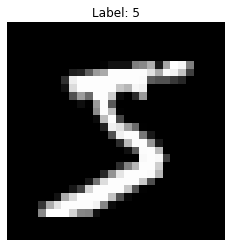

In [4]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display the shape of the training and testing sets
print(f'Training set shape: {X_train.shape}, {y_train.shape}')
print(f'Testing set shape: {X_test.shape}, {y_test.shape}')

# Display the first image and its label
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.axis('off')
plt.show()

### Normalizing and Reshaping Data

In [8]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape data to include the channel dimension
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Display the shape of the processed training and testing sets
print(f'Processed training set shape: {X_train.shape}, {y_train.shape}')
print(f'Processed testing set shape: {X_test.shape}, {y_test.shape}')

Processed training set shape: (60000, 28, 28, 1), (60000, 10)
Processed testing set shape: (10000, 28, 28, 1), (10000, 10)


### Building the Convolutional Neural Network

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 1600)              0         
                                                                 
 dense_4 (Dense)             (None, 128)              

### Training the Convolutional Neural Network

In [10]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


Epoch 1/10
1534/1875 [=======================>......] - ETA: 7s - loss: 0.2380 - accuracy: 0.9279

KeyboardInterrupt: 

### Model Evaluation

In [11]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

313/313 [==============================] - 2s 7ms/step - loss: 0.0556 - accuracy: 0.9817
Test accuracy: 0.9817


313/313 [==============================] - 2s 7ms/step


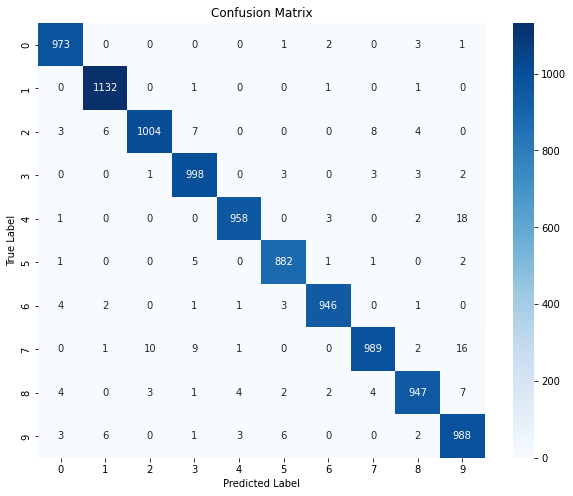

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict the labels for the test set
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=-1)
y_true = y_test.argmax(axis=-1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Practice Problems

1. Modify the CNN architecture to include additional convolutional and pooling layers. Train the modified model and compare its performance with the original model.

2. Implement data augmentation techniques (e.g., rotation, flipping, zooming) to increase the diversity of the training dataset. Train the CNN with the augmented dataset and evaluate its performance.

3. Write a function to save the trained model and load it later for inference. Test the function by saving the model, loading it, and using it to classify new images.

4. Extend the preprocessing pipeline to handle other digit datasets (e.g., SVHN). Build and train a CNN to classify images from the new dataset and evaluate its performance.


### Conclusion

In this lesson, we covered the entire process of building a Convolutional Neural Network (CNN) using Keras to classify handwritten digits from the MNIST dataset. 

We started by loading and preprocessing the dataset, normalizing and reshaping the data, and one-hot encoding the labels. We then built, trained, and evaluated the CNN, and used a confusion matrix to assess the model's performance. Understanding these steps is crucial for building effective image classification models.
